<a href="https://colab.research.google.com/github/yashsinghonline/yuvaintern-ai-ml-task3/blob/main/Telecom_Customer_Churn_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--> Loading Dataset...
Dataset successfully loaded! Shape: (7043, 21)

--> Preprocessing Data...
Preprocessing complete. Missing values count:
Series([], dtype: int64)

First 5 rows of processed data:
   tenure        Contract  MonthlyCharges  TotalCharges Churn
0       1  Month-to-month           29.85         29.85    No
1      34        One year           56.95       1889.50    No
2       2  Month-to-month           53.85        108.15   Yes
3      45        One year           42.30       1840.75    No
4       2  Month-to-month           70.70        151.65   Yes

--> Generating Visualizations...


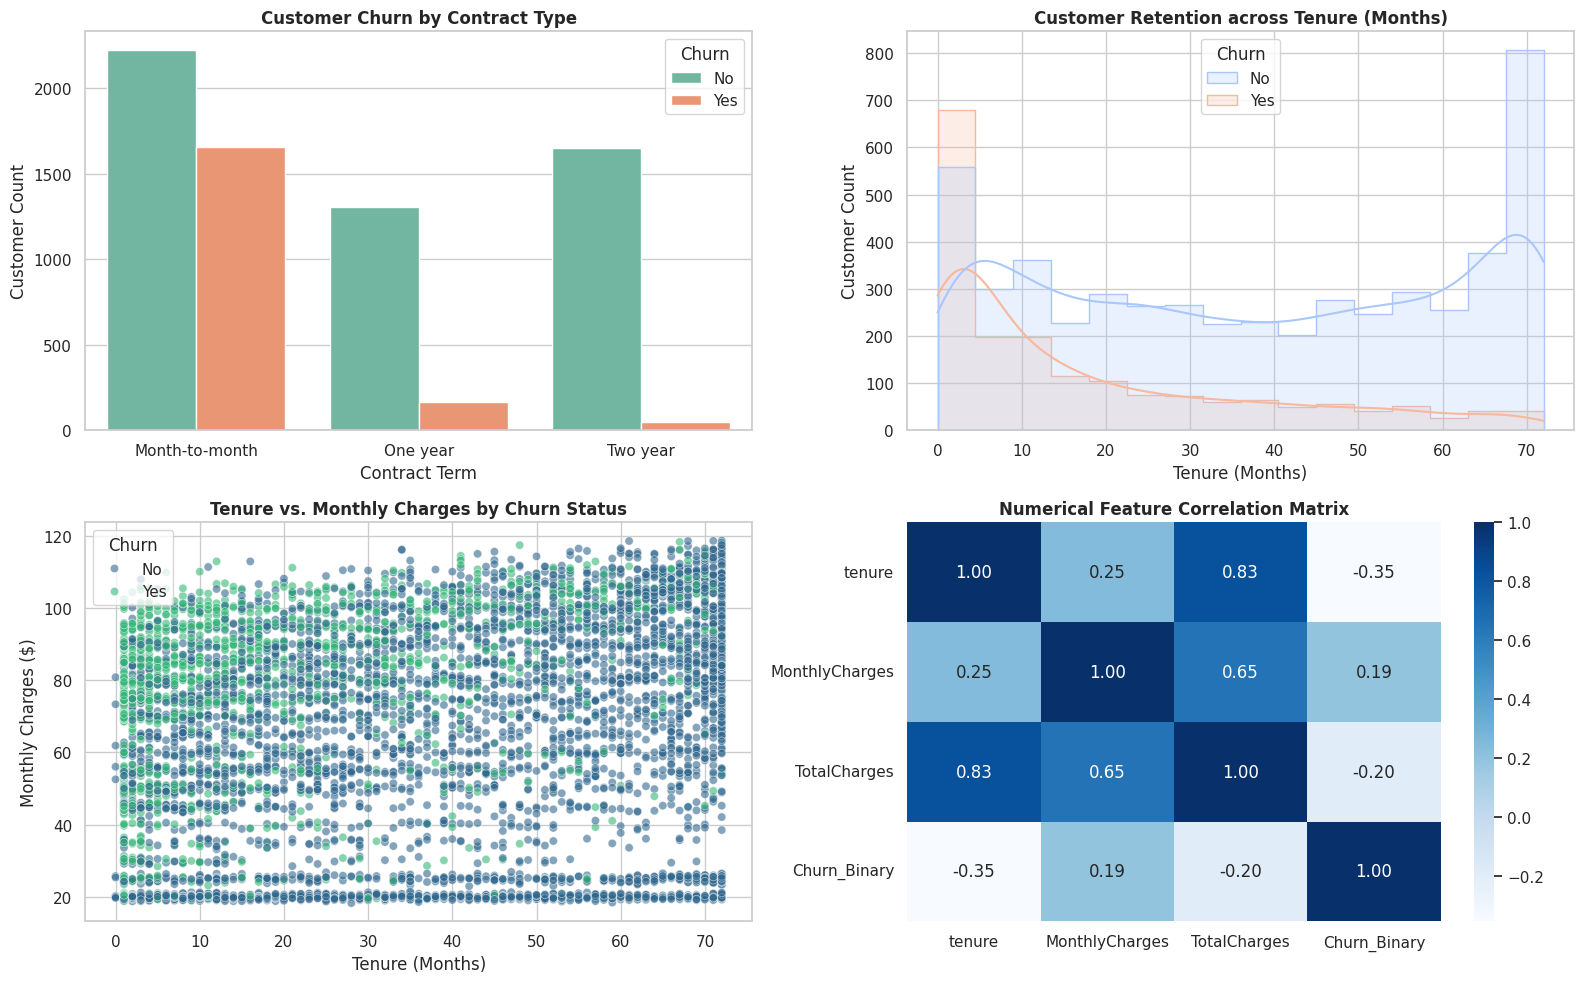


       SUMMARY ANALYSIS HIGHLIGHTS       
Total Customer Accounts:  7,043
Overall Churn Rate:       26.54%
Average Monthly Charge:   $64.76

Churn Rate Breakdown by Contract Type:
                Total Customers  Churn Rate (%)
Contract                                       
Month-to-month             3875           42.71
One year                   1473           11.27
Two year                   1695            2.83


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for seaborn
sns.set_theme(style="whitegrid")

# ==========================================
# STEP 1: LOAD DATASET DIRECTLY FROM URL
# ==========================================
print("--> Loading Dataset...")
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dataset successfully loaded! Shape: {df.shape}\n")

# ==========================================
# STEP 2 & 3: DATA EXPLORATION & PREPROCESSING (FIXED)
# ==========================================
print("--> Preprocessing Data...")

# 1. Convert TotalCharges to numeric (handles blank space strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# 2. Impute missing TotalCharges using lowercase 'tenure'
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

# 3. Drop unique identifiers & duplicate records
df.drop_duplicates(inplace=True)
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# 4. Map binary target variable (Yes -> 1, No -> 0)
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Preprocessing complete. Missing values count:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nFirst 5 rows of processed data:")
print(df[['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn']].head())
# ==========================================
# STEP 4 & 5: EXPLORATORY DATA ANALYSIS & PLOTS
# ==========================================
print("\n--> Generating Visualizations...")

plt.figure(figsize=(16, 10))

# Visual 1: Churn Count by Contract Type
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Customer Churn by Contract Type', fontsize=12, fontweight='bold')
plt.xlabel('Contract Term')
plt.ylabel('Customer Count')

# Visual 2: Churn Distribution across Tenure (Months)
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, element='step', palette='coolwarm')
plt.title('Customer Retention across Tenure (Months)', fontsize=12, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Customer Count')

# Visual 3: Monthly Charges vs. Tenure Scatterplot
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.6, palette='viridis')
plt.title('Tenure vs. Monthly Charges by Churn Status', fontsize=12, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')

# Visual 4: Numerical Feature Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f', cbar=True)
plt.title('Numerical Feature Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# STEP 6: PRINT KEY SUMMARY METRICS
# ==========================================
total_customers = len(df)
overall_churn_rate = (df['Churn_Binary'].sum() / total_customers) * 100
avg_monthly = df['MonthlyCharges'].mean()

print("\n" + "="*40)
print("       SUMMARY ANALYSIS HIGHLIGHTS       ")
print("="*40)
print(f"Total Customer Accounts:  {total_customers:,}")
print(f"Overall Churn Rate:       {overall_churn_rate:.2f}%")
print(f"Average Monthly Charge:   ${avg_monthly:.2f}")

print("\nChurn Rate Breakdown by Contract Type:")
contract_churn = df.groupby('Contract')['Churn_Binary'].agg(['count', 'mean'])
contract_churn['mean'] = contract_churn['mean'] * 100
contract_churn.columns = ['Total Customers', 'Churn Rate (%)']
print(contract_churn.round(2))